In [46]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pywt
from skimage.transform import resize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [37]:
# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Class label structure
data_dict = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

# -- Stage 1 --

## Load CWRU Bearing Data and Introduce Imbalance

In [38]:
# sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}


# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signal_idx = {"vibration": 6}.get(signal)
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    struct = mat[next(k for k in mat if not k.startswith("__"))]
    signal_data = struct.Y[signal_idx].Data.flatten()
    return pd.DataFrame(signal_data, columns=["vibration"])


def load_and_imbalance_paderborn_data(root_dir, imbalance_ratio):
    data_dict = {
        0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
        1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
        2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
    }

    all_data = {0: [], 1: [], 2: []}

    for label, (category, folders) in data_dict.items():
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            if not os.path.exists(folder_path):
                print(f"Missing folder: {folder_path}")
                continue

            mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
            if not mat_files:
                print(f"No .mat files in: {folder_path}")
                continue

            file_path = os.path.join(folder_path, mat_files[0])
            try:
                df = extract_signals_df(file_path)
                total_samples = len(df)

                # Subsample fault classes
                if label != 0:
                    fault_sample_limit = max(1000, total_samples // imbalance_ratio)
                    df = df.iloc[:fault_sample_limit]

                df["label"] = label
                all_data[label].append(df)
                print(f"Loaded {file_path} → {len(df)} samples")

            except Exception as e:
                print(f"Error reading {file_path}: {e}")

    # Combine all data
    final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
    final_df.rename(columns={"vibration": "signal"}, inplace=True)
    print(f"\nCombined dataset shape: {final_df.shape}\n")
    print(final_df.head())

    # Signal grouping
    df_signals = final_df[["signal", "label"]]
    grouped_signals = [
        df_signals[df_signals["label"] == label]["signal"].values.astype(float)
        for label in sorted(df_signals["label"].unique())
    ]
    
    # Datapoints per group
    # print("\n Count of samples in each group")
    for idx, signal_array in enumerate(grouped_signals):
        class_name = data_dict[idx][0]
        print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")

    return final_df, grouped_signals, data_dict


## Visualisation - Plotting class distribution and Raw vibrational data

In [39]:
# Prepare data for plotting
labels = [data_dict[label][0] for label in sorted(final_df['label'].unique())]
counts = [len(df_signals[df_signals['label'] == label]) for label in sorted(final_df['label'].unique())]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color='skyblue')
plt.title('Class Distribution After Applying Imbalance')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Plot vibration signals
# Plot 1000 samples from each class
num_classes_to_plot = len(grouped_signals)
plt.figure(figsize=(15, 4 * num_classes_to_plot))

for idx in range(num_classes_to_plot):
    signal_array = grouped_signals[idx]
    class_name = data_dict[idx][0]

    plt.subplot(num_classes_to_plot, 1, idx + 1)
    plt.plot(signal_array[:1000])
    plt.title(f"Class {idx} ({class_name})")
    plt.xlabel("Time Index")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'df_signals' is not defined

# --- Stage 2 ---

## Generate overlapping segments

In [40]:
def extract_segments(data, samples_per_block, interval_length, ignore_points=0):
    """
    Extract segments from data using vectorized indexing.

    Args:
        data (np.ndarray): Input signal data.
        samples_per_block (int): Length of each segment.
        interval_length (int): Step size between segment starts.
        ignore_points (int): Points to ignore at start and end.

    Returns:
        np.ndarray: Array of shape (n_segments, samples_per_block).
    """
    data = np.asarray(data).flatten()
    adjusted_length = len(data) - 2 * ignore_points
    n_segments = max(0, (adjusted_length - samples_per_block) // interval_length + 1)
    if n_segments == 0:
        return np.empty((0, samples_per_block), dtype=data.dtype)

    start_indices = ignore_points + np.arange(n_segments) * interval_length
    indices = start_indices[:, None] + np.arange(samples_per_block)
    return data[indices]

## Create Overlapping segments, One hot encoding

In [41]:
def segment_signals(grouped_signals, image_shape, samples_per_block, interval_length, n_classes):
    segment_list = []
    one_hot_labels = []
    integer_labels = []

    for class_idx, signal in enumerate(grouped_signals):
        segments = extract_segments(signal, samples_per_block, interval_length)
        n_segments = segments.shape[0]

        print(f"\nClass: {class_idx} Fault Label: {data_dict[class_idx][0]}")
        print(f"Segments: {n_segments} segments")
        print(f"Sample data (first 5 elements): {segments[0][:5] if n_segments > 0 else 'Empty'}")
        
        if n_segments > 0:
            one_hot = np.zeros((n_segments, n_classes))
            one_hot[:, class_idx] = 1
            labels = np.full((n_segments, 1), class_idx)

            segment_list.append(segments)
            one_hot_labels.append(one_hot)
            integer_labels.append(labels)

    return segment_list, one_hot_labels, integer_labels


# --- Stage 3 ---


## Time-Based Train-Test Split

In [42]:
def time_train_test_split(segment_list, one_hot_labels, integer_labels, train_ratio=0.8, n_classes=3):
    """
    Perform time-based class-wise train-test split for Paderborn dataset.

    Args:
        segment_list (List[np.ndarray]): List of segment arrays per class.
        one_hot_labels (List[np.ndarray]): One-hot encoded label arrays.
        integer_labels (List[np.ndarray]): Integer label arrays.
        train_ratio (float): Fraction of data for training.
        n_classes (int): Number of classes.

    Returns:
        tuple: (X_train, X_test, Y_train, Y_test, y_train, y_test)
    """
    X_train_list, X_test_list = [], []
    Y_train_list, Y_test_list = [], []
    y_train_list, y_test_list = [], []

    image_shape = (40, 40)

    for class_idx, (segments, one_hot, integer) in enumerate(zip(segment_list, one_hot_labels, integer_labels)):
        n_segments = segments.shape[0]
        train_size = int(n_segments * train_ratio)
        train_segments = segments[:train_size]
        test_segments = segments[train_size:]

        print(f"\nClass {class_idx} (Label {class_idx}):")
        print(f"Train segments: {train_segments.shape[0]}")
        print(f"Test segments: {test_segments.shape[0]}")

        if train_segments.shape[0] > 0:
            X_train_list.append(train_segments)
            Y_train_list.append(one_hot[:train_size])
            y_train_list.append(integer[:train_size])

        if test_segments.shape[0] > 0:
            X_test_list.append(test_segments)
            Y_test_list.append(one_hot[train_size:])
            y_test_list.append(integer[train_size:])

    X_train = np.vstack(X_train_list) if X_train_list else np.empty((0, 1600))
    X_test = np.vstack(X_test_list) if X_test_list else np.empty((0, 1600))
    Y_train = np.vstack(Y_train_list) if Y_train_list else np.empty((0, n_classes))
    Y_test = np.vstack(Y_test_list) if Y_test_list else np.empty((0, n_classes))
    y_train = np.vstack(y_train_list) if y_train_list else np.empty((0, 1))
    y_test = np.vstack(y_test_list) if y_test_list else np.empty((0, 1))

    X_2D_train = X_train.reshape([-1, image_shape[0], image_shape[1], 1])
    X_2D_test = X_test.reshape([-1, image_shape[0], image_shape[1], 1])

    print(f"\nFinal X_train shape: {X_2D_train.shape}")
    print(f"Final Y_train shape: {Y_train.shape}")
    print(f"Final y_train shape: {y_train.shape}")
    print(f"Final X_test shape: {X_2D_test.shape}")
    print(f"Final Y_test shape: {Y_test.shape}")
    print(f"Final y_test shape: {y_test.shape}")

    return X_2D_train, X_2D_test, Y_train, Y_test, y_train, y_test


In [43]:
root_dir = './Paderborn_PreCase1_Data'
imbalance_ratio = 50
interval_length = 1600
samples_per_block = 1600
train_ratio = 0.8
n_classes = 3

# Stage 1: Load and apply imbalance
final_df, grouped_signals, data_dict = load_and_imbalance_paderborn_data(root_dir, imbalance_ratio)

# Stage 2: Segment signals and generate scalograms
segments, one_hot_labels, integer_labels = segment_signals(grouped_signals, image_shape=(40, 40), samples_per_block=1600, interval_length=1600, n_classes=3)

# Stage 3: Train-test split
X_2D_train, X_2D_test, Y_train, Y_test, y_label_train, y_label_test = time_train_test_split(
    segments, one_hot_labels, integer_labels, train_ratio, n_classes
)

# # Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

# X_1D_train = X_train_split.reshape([-1, samples_per_block, 1])
# X_1D_test = X_test_split.reshape([-1, samples_per_block, 1])
# input_shape = (samples_per_block, 1)   # Reshaped input

Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat → 256001 samples
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat → 256001 samples
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat → 256000 samples
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat → 259996 samples
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat → 256001 samples
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat → 5120 samples
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat → 5120 samples
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat → 5121 samples
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat → 5120 samples
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat → 5120 samples
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat → 5121 samples
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat → 5121 samples
Loaded ./Paderborn_PreCase1_Data/KI16/N09_M07_F10_KI16_1.mat → 5120 samples
L

# Model definition

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
print(f"X_2D_train shape: {X_2D_train.shape}") 
print(f"X_2D_test shape: {X_2D_test.shape}")  
print(f"Y_train shape: {Y_train.shape}") 
print(f"Y_test shape: {Y_test.shape}") 
print(f"Y_train shape: {y_label_train.shape}") 
print(f"Y_test shape: {y_label_test.shape}")  

class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape= (40, 40, 1)),
            layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(100, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(96, activation='relu'),
            layers.Dense(3, activation='softmax')
        ])
        model.compile(
            optimizer='adam',
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=['accuracy']
        )
        return model

X_2D_train shape: (665, 40, 40, 1)
X_2D_test shape: (169, 40, 40, 1)
Y_train shape: (665, 3)
Y_test shape: (169, 3)
Y_train shape: (665, 1)
Y_test shape: (169, 1)


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential, load_model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, balanced_accuracy_score

# Condition mapping
condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

# Training with k-fold validation
foldername = "Paderborn_results/Paderborn_CNN2D-NOL/"
kSplits = 5
accuracy_1D = []
precision_1D = []
recall_1D = []
f1_1D = []
precision_1D_macro = []
recall_1D_macro = []
f1_1D_macro = []
log_loss_1D = []
balanced_accuracy_1D = []
accuracy_1D_test = []
precision_1D_test = []
recall_1D_test = []
f1_1D_test = []
precision_1D_test_macro = []
recall_1D_test_macro = []
f1_1D_test_macro = []
log_loss_1D_test = []
balanced_accuracy_1D_test = []

# Initialize arrays for validation predictions across folds
n_train_samples = Y_train.shape[0]
pred_all_val = np.zeros((n_train_samples, 3))  # Store validation predictions
y_val_true = np.zeros((n_train_samples, 3))    # Store true validation labels
kfold_test_len = []                             # Store size of each validation fold
fl1 = 0

early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True)

# Train the model with k-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_2D_train, y_label_train.flatten())):
    checkpoint_filepath = foldername + f"best_model_fold_{fold+1}.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    Classification_2D = CNN_2D()
    history = Classification_2D.model.fit(
        X_2D_train[train_idx], Y_train[train_idx],
        validation_data=(X_2D_train[val_idx], Y_train[val_idx]),
        epochs=200,
        verbose=1,
        callbacks=[checkpoint, early_stop]
    )
    print(f"Best model saved at: {checkpoint_filepath}")
    CNN_2D_best_model = load_model(checkpoint_filepath)
    print("Best model loaded successfully!")

    # Store validation predictions
    fl2 = fl1 + len(val_idx)
    pred_all_val[fl1:fl2, :] = CNN_2D_best_model.predict(X_2D_train[val_idx])
    y_val_true[fl1:fl2, :] = Y_train[val_idx]
    kfold_test_len.append(fl2 - fl1)
    fl1 = fl2

    # Train set metrics (for the current fold's training data)
    y_pred_proba_train = CNN_2D_best_model.predict(X_2D_train[train_idx])
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(Y_train[train_idx], axis=1)

    accuracy_1D.append(accuracy_score(y_true_train, y_pred_train))
    precision_1D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_1D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_1D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    precision_1D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_1D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_1D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))
    log_loss_1D.append(log_loss(Y_train[train_idx], y_pred_proba_train))
    balanced_accuracy_1D.append(balanced_accuracy_score(y_true_train, y_pred_train))

    # Test set metrics
    y_pred_proba_test = CNN_2D_best_model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

     # Compute confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()
    
    # Save path
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    
    # Save and show
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    accuracy_1D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_1D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_1D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_1D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_1D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_1D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_1D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_1D_test.append(log_loss(Y_test, y_pred_proba_test))
    balanced_accuracy_1D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

In [52]:
# Print average metrics across folds
print("\nAverage Training Metrics Across Folds (in %):")
print(f"Accuracy: {100 * np.mean(accuracy_1D):.2f}% ± {100 * np.std(accuracy_1D):.2f}%")
print(f"Precision: {100 * np.mean(precision_1D):.2f}% ± {100 * np.std(precision_1D):.2f}%")
print(f"Recall: {100 * np.mean(recall_1D):.2f}% ± {100 * np.std(recall_1D):.2f}%")
print(f"F1 Score: {100 * np.mean(f1_1D):.2f}% ± {100 * np.std(f1_1D):.2f}%")
print(f"Precision-Macro: {100 * np.mean(precision_1D_macro):.2f}% ± {100 * np.std(precision_1D_macro):.2f}%")
print(f"Recall-Macro: {100 * np.mean(recall_1D_macro):.2f}% ± {100 * np.std(recall_1D_macro):.2f}%")
print(f"F1 Score-Macro: {100 * np.mean(f1_1D_macro):.2f}% ± {100 * np.std(f1_1D_macro):.2f}%")
print(f"Log Loss: {np.mean(log_loss_1D):.4f} ± {np.std(log_loss_1D):.4f}")
print(f"Balanced Accuracy: {100 * np.mean(balanced_accuracy_1D):.2f}% ± {100 * np.std(balanced_accuracy_1D):.2f}%")



print("\nAverage Test Metrics Across Folds:")
print(f"Accuracy: {100 * np.mean(accuracy_1D_test):.2f}% ± {100 * np.std(accuracy_1D_test):.2f}%")
print(f"Precision: {100 * np.mean(precision_1D_test):.2f}% ± {100 * np.std(precision_1D_test):.2f}%")
print(f"Recall: {100 * np.mean(recall_1D_test):.2f}% ± {100 * np.std(recall_1D_test):.2f}%")
print(f"F1 Score: {100 * np.mean(f1_1D_test):.2f}% ± {100 * np.std(f1_1D_test):.2f}%")
print(f"Precision-Macro: {100 * np.mean(precision_1D_test_macro):.2f}% ± {100 * np.std(precision_1D_test_macro):.2f}%")
print(f"Recall-Macro: {100 * np.mean(recall_1D_test_macro):.2f}% ± {100 * np.std(recall_1D_test_macro):.2f}%")
print(f"F1 Score-Macro: {100 * np.mean(f1_1D_test_macro):.2f}% ± {100 * np.std(f1_1D_test_macro):.2f}%")
print(f"Log Loss: {np.mean(log_loss_1D_test):.4f} ± {np.std(log_loss_1D_test):.4f}")
print(f"Balanced Accuracy: {100 * np.mean(balanced_accuracy_1D_test):.2f}% ± {100 * np.std(balanced_accuracy_1D_test):.2f}%")


# Distribution printing (from previous request)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("\nBlocks per class in X_train:")
print(df_train_orig.to_string(index=False))

train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))


Average Training Metrics Across Folds (in %):
Accuracy: 99.02% ± 0.55%
Precision: 99.20% ± 0.46%
Recall: 99.02% ± 0.55%
F1 Score: 98.78% ± 0.80%
Precision-Macro: 92.03% ± 3.13%
Recall-Macro: 81.93% ± 10.21%
F1 Score-Macro: 80.79% ± 12.22%
Log Loss: 0.0372 ± 0.0224
Balanced Accuracy: 81.93% ± 10.21%

Average Test Metrics Across Folds:
Accuracy: 96.45% ± 0.84%
Precision: 95.31% ± 1.12%
Recall: 96.45% ± 0.84%
F1 Score: 95.69% ± 0.96%
Precision-Macro: 60.98% ± 16.31%
Recall-Macro: 50.00% ± 11.79%
F1 Score-Macro: 53.03% ± 13.14%
Log Loss: 0.3063 ± 0.0130
Balanced Accuracy: 50.00% ± 11.79%

Blocks per class in X_train:
Condition  Blocks
  Healthy     641
 OR Fault      12
 IR Fault      12

X_train_split and Y_train distribution:
Condition  Blocks
  Healthy     641
 OR Fault      12
 IR Fault      12

X_test_split and Y_test distribution:
Condition  Blocks
  Healthy     161
 OR Fault       4
 IR Fault       4

y_train_split distribution (assumed):
Condition  Blocks
  Healthy     641
 OR Fau

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7792 - loss: 0.7512
Epoch 1: val_accuracy improved from -inf to 0.96992, saving model to Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_1.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.7865 - loss: 0.7386 - val_accuracy: 0.9699 - val_loss: 0.1497
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9499 - loss: 0.2506
Epoch 2: val_accuracy did not improve from 0.96992
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.9506 - loss: 0.2495 - val_accuracy: 0.9699 - val_loss: 0.1472
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9499 - loss: 0.2061
Epoch 3: val_accuracy did not improve from 0.96992
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - accuracy: 0.9506 - loss: 0.2038 - val_accuracy: 0.9699 - val_loss: 0.1173
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9499 - loss: 0.1855
Epoch 4: val_accuracy did not improve from 0.96992
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.9506 - loss: 0.1838 - val_accuracy: 0.9699 - val_loss: 0.0961
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9499 - loss: 0.1585
Epoch 5: val_accuracy did not i

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9513 - loss: 0.1254 - val_accuracy: 0.9774 - val_loss: 0.0337
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9553 - loss: 0.1344
Epoch 8: val_accuracy improved from 0.97744 to 0.98496, saving model to Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_1.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9560 - loss: 0.1315 - val_accuracy: 0.9850 - val_loss: 0.0315
Epoch 9/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9628 - loss: 0.1036
Epoch 9: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9638 - loss: 0.1020 - val_accuracy: 0.9850 - val_loss: 0.0239
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9697 - loss: 0.1510
Epoch 10: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9701 - loss: 0.1473 - val_accuracy: 0.9850 - val_loss: 0.0255
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9871 - loss: 0.0787
Epoch 11: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.9870 - loss: 0.0777 - val_accuracy: 0.9850 - val_loss: 0.0218
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9701 - loss: 0.0992
Epoch 12: val_accuracy did

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.9781 - loss: 0.0794 - val_accuracy: 0.9925 - val_loss: 0.0225
Epoch 14/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9783 - loss: 0.0715
Epoch 14: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.9789 - loss: 0.0700 - val_accuracy: 0.9850 - val_loss: 0.0219
Epoch 15/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9723 - loss: 0.0685
Epoch 15: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.9724 - loss: 0.0678 - val_accuracy: 0.9925 - val_loss: 0.0357
Epoch 16/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9762 - loss: 0.0694
Epoch 16: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.9766 - loss: 0.0683 - val_accuracy: 0.9850 - val_loss: 0.0219
Epoch 17/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9753 - loss: 0.0619
Epoch 17: val_accuracy i

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 292ms/step - accuracy: 0.9756 - loss: 0.0608 - val_accuracy: 1.0000 - val_loss: 0.0210
Epoch 18/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9831 - loss: 0.0621
Epoch 18: val_accuracy did not improve from 1.00000
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.9835 - loss: 0.0607 - val_accuracy: 0.9699 - val_loss: 0.0600
Epoch 19/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9631 - loss: 0.1738
Epoch 19: val_accuracy did not improve from 1.00000
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.9638 - loss: 0.1694 - val_accuracy: 0.9774 - val_loss: 0.0284
Epoch 20/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9679 - loss: 0.0717
Epoch 20: val_accuracy did not improve from 1.00000
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.9686 - loss: 0.0705 - val_accuracy: 0.9925 - val_loss: 0.0215
Epoch 21/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9787 - loss: 0.0523
Epoch 21: val_accuracy d

Best model loaded successfully!
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


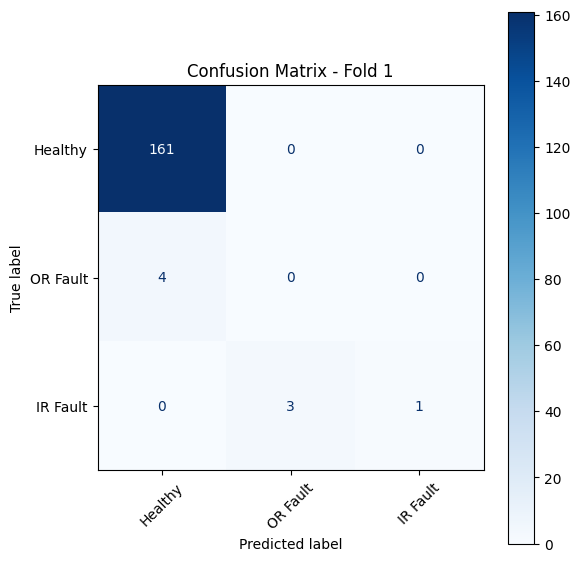

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn_CNN2D-NOL/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.8054 - loss: 0.7230
Epoch 1: val_accuracy improved from -inf to 0.96241, saving model to Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_2.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.8117 - loss: 0.7131 - val_accuracy: 0.9624 - val_loss: 0.2059
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9535 - loss: 0.2556
Epoch 2: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.9541 - loss: 0.2547 - val_accuracy: 0.9624 - val_loss: 0.1793
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9535 - loss: 0.2168
Epoch 3: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.9541 - loss: 0.2143 - val_accuracy: 0.9624 - val_loss: 0.1483
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9535 - loss: 0.1963
Epoch 4: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.9541 - loss: 0.1940 - val_accuracy: 0.9624 - val_loss: 0.1331
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9535 - loss: 0.1988
Epoch 5: val_accuracy did not i

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.9636 - loss: 0.1083 - val_accuracy: 0.9850 - val_loss: 0.0397
Epoch 9/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9742 - loss: 0.0971
Epoch 9: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.9746 - loss: 0.0954 - val_accuracy: 0.9774 - val_loss: 0.0373
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9703 - loss: 0.1368
Epoch 10: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.9709 - loss: 0.1336 - val_accuracy: 0.9850 - val_loss: 0.0318
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9789 - loss: 0.1000
Epoch 11: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.9792 - loss: 0.0985 - val_accuracy: 0.9850 - val_loss: 0.0395
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9724 - loss: 0.0816
Epoch 12: val_accuracy did

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.9847 - loss: 0.0181 - val_accuracy: 0.9925 - val_loss: 0.0147
Epoch 45/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9927 - loss: 0.0180
Epoch 45: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.9928 - loss: 0.0178 - val_accuracy: 0.9925 - val_loss: 0.0180
Epoch 46/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9883 - loss: 0.0690
Epoch 46: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.9885 - loss: 0.0670 - val_accuracy: 0.9925 - val_loss: 0.0183
Epoch 47/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9886 - loss: 0.0276
Epoch 47: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.9887 - loss: 0.0271 - val_accuracy: 0.9850 - val_loss: 0.0208
Epoch 48/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9915 - loss: 0.0244
Epoch 48: val_accuracy d

Best model loaded successfully!
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


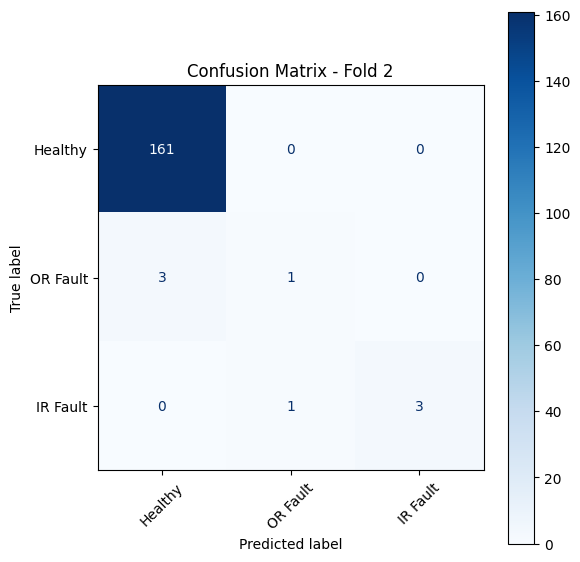

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn_CNN2D-NOL/confusion_matrices/confusion_matrix_fold_2.png
Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9156 - loss: 0.7221
Epoch 1: val_accuracy improved from -inf to 0.96241, saving model to Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_3.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.9176 - loss: 0.7153 - val_accuracy: 0.9624 - val_loss: 0.2802
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9535 - loss: 0.2705
Epoch 2: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9541 - loss: 0.2683 - val_accuracy: 0.9624 - val_loss: 0.1479
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9535 - loss: 0.2241
Epoch 3: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.9541 - loss: 0.2221 - val_accuracy: 0.9624 - val_loss: 0.1330
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9535 - loss: 0.2151
Epoch 4: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9541 - loss: 0.2125 - val_accuracy: 0.9624 - val_loss: 0.1235
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9535 - loss: 0.2161
Epoch 5: val_accuracy did not i

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.9541 - loss: 0.1214 - val_accuracy: 0.9850 - val_loss: 0.0472
Epoch 9/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9683 - loss: 0.0935
Epoch 9: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9690 - loss: 0.0921 - val_accuracy: 0.9850 - val_loss: 0.0355
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9697 - loss: 0.0882
Epoch 10: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9702 - loss: 0.0866 - val_accuracy: 0.9850 - val_loss: 0.0312
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9743 - loss: 0.0788
Epoch 11: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9746 - loss: 0.0777 - val_accuracy: 0.9774 - val_loss: 0.0427
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9753 - loss: 0.0936
Epoch 12: val_accuracy did

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9670 - loss: 0.0531 - val_accuracy: 0.9925 - val_loss: 0.0260
Epoch 22/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9785 - loss: 0.0756
Epoch 22: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9788 - loss: 0.0739 - val_accuracy: 0.9925 - val_loss: 0.0256
Epoch 23/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9732 - loss: 0.0739
Epoch 23: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9737 - loss: 0.0724 - val_accuracy: 0.9774 - val_loss: 0.1086
Epoch 24/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9719 - loss: 0.0660
Epoch 24: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.9725 - loss: 0.0645 - val_accuracy: 0.9925 - val_loss: 0.0240
Epoch 25/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9779 - loss: 0.0803
Epoch 25: val_accuracy d

Best model saved at: Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_3.h5
Best model loaded successfully!
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


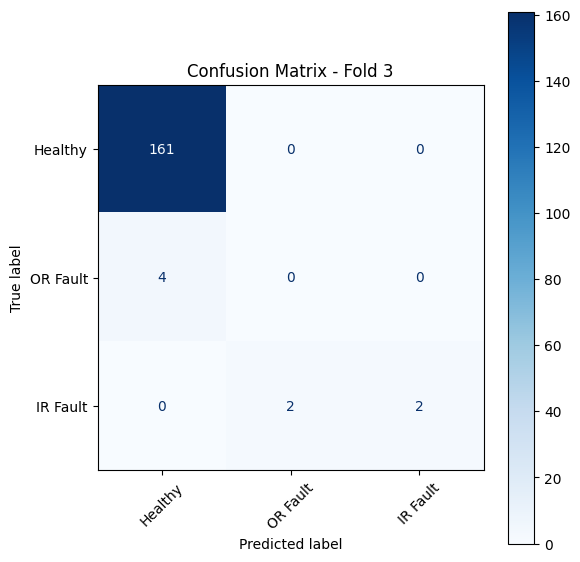

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn_CNN2D-NOL/confusion_matrices/confusion_matrix_fold_3.png
Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8207 - loss: 0.7481
Epoch 1: val_accuracy improved from -inf to 0.96241, saving model to Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_4.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.8265 - loss: 0.7400 - val_accuracy: 0.9624 - val_loss: 0.2947
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9535 - loss: 0.2446
Epoch 2: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9541 - loss: 0.2422 - val_accuracy: 0.9624 - val_loss: 0.1828
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9535 - loss: 0.2051
Epoch 3: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.9541 - loss: 0.2022 - val_accuracy: 0.9624 - val_loss: 0.1839
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9535 - loss: 0.1856
Epoch 4: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9541 - loss: 0.1832 - val_accuracy: 0.9624 - val_loss: 0.1622
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9535 - loss: 0.1616
Epoch 5: val_accuracy did not i

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.9555 - loss: 0.1310 - val_accuracy: 0.9774 - val_loss: 0.1217
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9667 - loss: 0.1468
Epoch 10: val_accuracy did not improve from 0.97744
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9673 - loss: 0.1428 - val_accuracy: 0.9774 - val_loss: 0.1065
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9683 - loss: 0.1037
Epoch 11: val_accuracy did not improve from 0.97744
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.9690 - loss: 0.1013 - val_accuracy: 0.9774 - val_loss: 0.0891
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9753 - loss: 0.0841
Epoch 12: val_accuracy did not improve from 0.97744
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.9757 - loss: 0.0823 - val_accuracy: 0.9774 - val_loss: 0.0693
Epoch 13/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9707 - loss: 0.0928
Epoch 13: val_accuracy d

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.9703 - loss: 0.0706 - val_accuracy: 0.9850 - val_loss: 0.1026
Epoch 18/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9733 - loss: 0.0803
Epoch 18: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.9736 - loss: 0.0785 - val_accuracy: 0.9774 - val_loss: 0.0686
Epoch 19/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9810 - loss: 0.0482
Epoch 19: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9813 - loss: 0.0472 - val_accuracy: 0.9774 - val_loss: 0.0995
Epoch 20/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9742 - loss: 0.0559
Epoch 20: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9747 - loss: 0.0547 - val_accuracy: 0.9774 - val_loss: 0.0622
Epoch 21/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9706 - loss: 0.0459
Epoch 21: val_accuracy d

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9841 - loss: 0.0294 - val_accuracy: 0.9925 - val_loss: 0.1246
Epoch 45/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9884 - loss: 0.0231
Epoch 45: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9887 - loss: 0.0228 - val_accuracy: 0.9774 - val_loss: 0.1151
Epoch 46/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9910 - loss: 0.0191
Epoch 46: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9908 - loss: 0.0192 - val_accuracy: 0.9774 - val_loss: 0.1210
Epoch 47/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9732 - loss: 0.0309
Epoch 47: val_accuracy did not improve from 0.99248
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9737 - loss: 0.0305 - val_accuracy: 0.9774 - val_loss: 0.0714
Epoch 48/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9844 - loss: 0.0211
Epoch 48: val_accuracy d

Best model saved at: Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_4.h5
Best model loaded successfully!
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


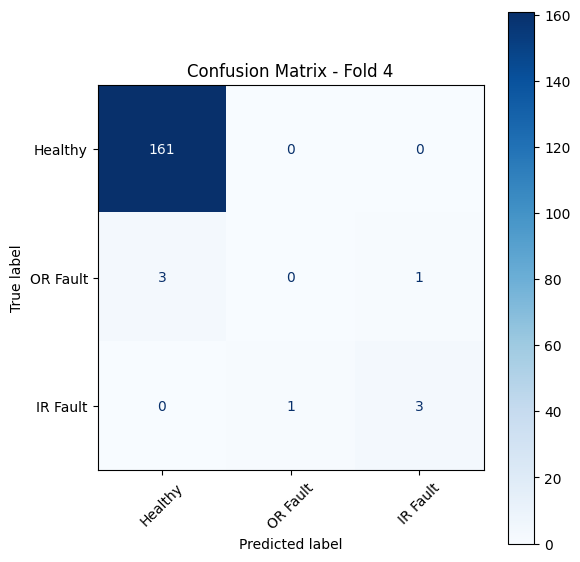

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn_CNN2D-NOL/confusion_matrices/confusion_matrix_fold_4.png
Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7891 - loss: 0.7377
Epoch 1: val_accuracy improved from -inf to 0.96241, saving model to Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_5.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.7961 - loss: 0.7236 - val_accuracy: 0.9624 - val_loss: 0.1921
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9535 - loss: 0.2548
Epoch 2: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9541 - loss: 0.2538 - val_accuracy: 0.9624 - val_loss: 0.1714
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9535 - loss: 0.2134
Epoch 3: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.9541 - loss: 0.2119 - val_accuracy: 0.9624 - val_loss: 0.1625
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9535 - loss: 0.1857
Epoch 4: val_accuracy did not improve from 0.96241
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.9541 - loss: 0.1835 - val_accuracy: 0.9624 - val_loss: 0.1538
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9535 - loss: 0.1266
Epoch 5: val_accuracy did not i

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9601 - loss: 0.0797 - val_accuracy: 0.9774 - val_loss: 0.1162
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9756 - loss: 0.0687
Epoch 8: val_accuracy did not improve from 0.97744
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9760 - loss: 0.0681 - val_accuracy: 0.9774 - val_loss: 0.1129
Epoch 9/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9747 - loss: 0.0573
Epoch 9: val_accuracy did not improve from 0.97744
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9750 - loss: 0.0567 - val_accuracy: 0.9774 - val_loss: 0.1160
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9745 - loss: 0.0549
Epoch 10: val_accuracy did not improve from 0.97744
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9749 - loss: 0.0547 - val_accuracy: 0.9699 - val_loss: 0.1221
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9756 - loss: 0.0535
Epoch 11: val_accuracy impro

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9760 - loss: 0.0529 - val_accuracy: 0.9850 - val_loss: 0.1373
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9731 - loss: 0.0550 
Epoch 12: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.9733 - loss: 0.0548 - val_accuracy: 0.9850 - val_loss: 0.0997
Epoch 13/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9672 - loss: 0.0623
Epoch 13: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9678 - loss: 0.0618 - val_accuracy: 0.9850 - val_loss: 0.1129
Epoch 14/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9681 - loss: 0.0636
Epoch 14: val_accuracy did not improve from 0.98496
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9687 - loss: 0.0631 - val_accuracy: 0.9850 - val_loss: 0.1027
Epoch 15/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9701 - loss: 0.0567
Epoch 15: val_accuracy d

Best model saved at: Paderborn_results/Paderborn_CNN2D-NOL/best_model_fold_5.h5
Best model loaded successfully!
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


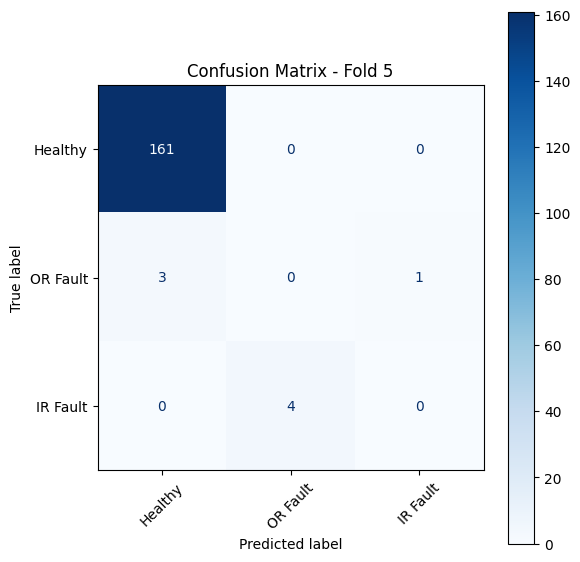

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn_CNN2D-NOL/confusion_matrices/confusion_matrix_fold_5.png

Average Training Metrics Across Folds:
Accuracy: 0.9902 ± 0.0055
Precision: 0.9920 ± 0.0046
Recall: 0.9902 ± 0.0055
F1 Score: 0.9878 ± 0.0080
Precision-Macro: 0.9203 ± 0.0313
Recall-Macro: 0.8193 ± 0.1021
F1 Score-Macro: 0.8079 ± 0.1222
Log Loss: 0.0372 ± 0.0224
Balanced Accuracy: 0.8193 ± 0.1021

Average Test Metrics Across Folds:
Accuracy: 0.9645 ± 0.0084
Precision: 0.9531 ± 0.0112
Recall: 0.9645 ± 0.0084
F1 Score: 0.9569 ± 0.0096
Precision-Macro: 0.6098 ± 0.1631
Recall-Macro: 0.5000 ± 0.1179
F1 Score-Macro: 0.5303 ± 0.1314
Log Loss: 0.3063 ± 0.0130
Balanced Accuracy: 0.5000 ± 0.1179

Blocks per class in X_train:
Condition  Blocks
  Healthy     641
 OR Fault      12
 IR Fault      12

X_train_split and Y_train distribution:
Condition  Blocks
  Healthy     641
 OR Fault      12
 IR Fault      12

X_test_split and Y_test distribution:
Condition  Blocks
  Healthy  

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


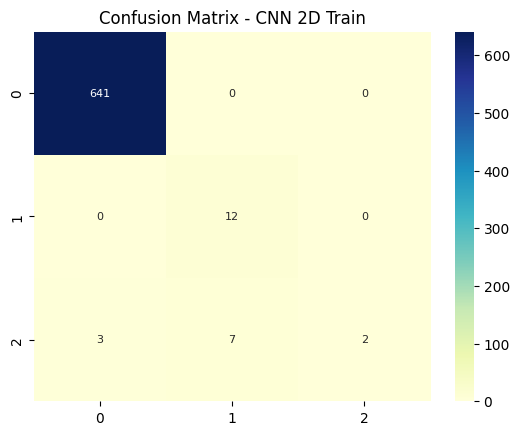

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


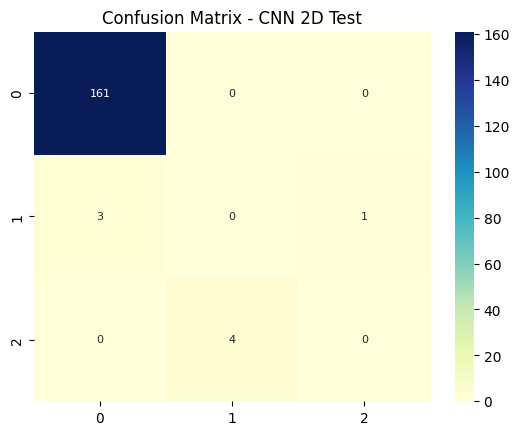

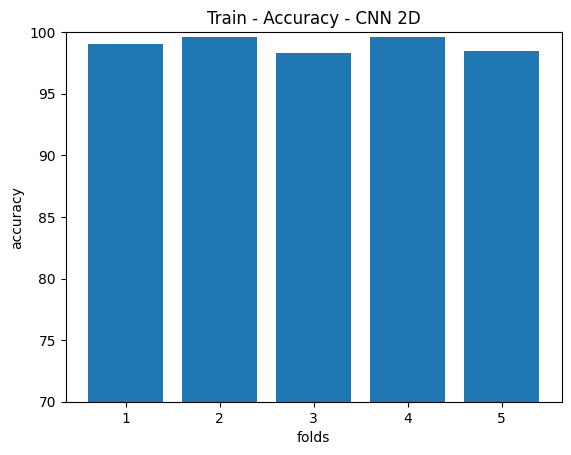

NameError: name 'CNN_2D_train_accuracy' is not defined

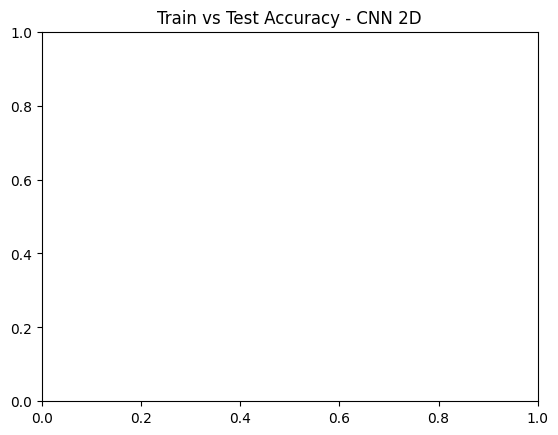

In [51]:
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    return confusion_matrix(y_true, y_pred)

plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, Y_train), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, Y_test), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_1D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()

In [53]:
# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, kSplits + 1),
    
    'Train Accuracy (%)': np.array(accuracy_1D) * 100,
    'Test Accuracy (%)': np.array(accuracy_1D_test) * 100,

    'Train Precision (%)': np.array(precision_1D) * 100,
    'Test Precision (%)': np.array(precision_1D_test) * 100,

    'Train Recall (%)': np.array(recall_1D) * 100,
    'Test Recall (%)': np.array(recall_1D_test) * 100,

    'Train F1-score (%)': np.array(f1_1D) * 100,
    'Test F1-score (%)': np.array(f1_1D_test) * 100,

    'Train Precision-Macro (%)': np.array(precision_1D_macro) * 100,
    'Test Precision-Macro (%)': np.array(precision_1D_test_macro) * 100,

    'Train Recall-Macro (%)': np.array(recall_1D_macro) * 100,
    'Test Recall-Macro (%)': np.array(recall_1D_test_macro) * 100,

    'Train F1-score (%)': np.array(f1_1D_macro) * 100,
    'Test F1-score (%)': np.array(f1_1D_test_macro) * 100,

    'Train Log Loss': log_loss_1D,
    'Test Log Loss': log_loss_1D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_1D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_1D_test) * 100,
})

metrics_df

,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Precision-Macro (%),Test Precision-Macro (%),Train Recall-Macro (%),Test Recall-Macro (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,99.060150,95.857988,99.126092,95.323651,99.060150,95.857988,85.761215,46.257669,94.250270,65.858586,83.333333,41.666667,0.047661,0.312222,83.333333,41.666667
1,2,99.624060,97.633136,99.686717,97.073892,99.624060,97.633136,92.803030,72.708181,94.444444,82.723577,92.592593,66.666667,0.009089,0.302045,92.592593,66.666667
2,3,98.308271,96.449704,98.462286,95.323651,98.308271,96.449704,67.771570,55.146558,91.281310,65.858586,70.000000,50.000000,0.072662,0.326425,70.000000,50.000000
3,4,99.624060,97.041420,99.692413,95.298744,99.624060,97.041420,92.962963,58.025641,93.939394,57.723577,93.333333,58.333333,0.018740,0.304129,93.333333,58.333333
4,5,98.496241,95.266272,99.038402,93.523596,98.496241,95.266272,64.658901,33.025641,86.209659,32.723577,70.370370,33.333333,0.037823,0.286756,70.370370,33.333333


In [ ]:
## turn into excel
metrics_df.to_excel(os.path.join(foldername, "Imbalanced_Paderborn.xlsx"), index=False)